Importing required library and functions

In [1]:
import sys
import os
import shutil
import platform
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt;
# for this course we use locally stored version of pyemu and flopy to avoid version conflicts
import pyemu
import flopy
assert "dependencies" in flopy.__file__
assert "dependencies" in pyemu.__file__
# herebedragons.py contains a series of utility functions that help us manage the tutorial repository
sys.path.insert(0,"..")
import herebedragons as hbd

Setting up MODFLOW files dir

Getting executables to run PEST

In [2]:
# folder containing original model files
org_d = os.path.join('..', '..', '..', "results", '3d_injection_modeling_PMW-6')

# a dir to hold a copy of the org model files
tmp_d = os.path.join('PMW-6_mf6')

if os.path.exists(tmp_d):
    shutil.rmtree(tmp_d)
shutil.copytree(org_d,tmp_d)

# get executables
hbd.prep_bins(tmp_d)
# get dependency folders
hbd.prep_deps(tmp_d)

In [3]:
sim_ws = os.path.join('..', '..', '..', "results", "3d_injection_modeling_PMW-6")
os.listdir(tmp_d)

['heads.csv',
 'inschek.exe',
 'k_layer1.txt',
 'k_layer2.txt',
 'k_layer3.txt',
 'mf5to6.exe',
 'mf6.exe',
 'mfsim.lst',
 'mfsim.nam',
 'MLAC-model.bud',
 'MLAC-model.chd',
 'MLAC-model.dis',
 'MLAC-model.dis.grb',
 'MLAC-model.hds',
 'MLAC-model.ic',
 'MLAC-model.ims',
 'MLAC-model.lst',
 'MLAC-model.nam',
 'MLAC-model.npf',
 'MLAC-model.obs',
 'MLAC-model.oc',
 'MLAC-model.sto',
 'MLAC-model.tdis',
 'MLAC-model.wel',
 'mp7.exe',
 'pest.exe',
 'pestchek.exe',
 'pestpp-da.exe',
 'pestpp-glm.exe',
 'pestpp-ies.exe',
 'pestpp-mou.exe',
 'pestpp-opt.exe',
 'pestpp-sen.exe',
 'pestpp-swp.exe',
 'simulated_data',
 'tempchek.exe',
 'well_location_and_times.csv',
 'zbud6.exe']

Loading MODFLOW simulation to obtain discretization information

In [4]:
sim = flopy.mf6.MFSimulation.load(sim_ws=tmp_d)
gwf = sim.get_model()

#pyemu.os_utils.run("mf6", cwd=tmp_d, verbose=True)

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package chd...
    loading package wel...
    loading package oc...
    loading package obs...
  loading solution package mlac-model...


Spatial reference

In [5]:
os.path.join(tmp_d, "MLAC-model.nam")

'PMW-6_mf6\\MLAC-model.nam'

In [89]:
sr = pyemu.helpers.SpatialReference.from_namfile(
    os.path.join(tmp_d, "MLAC-model.nam"), 
    delr=gwf.dis.delr.array, 
    delc=gwf.dis.delc.array,
)

   could not remove start_datetime


In [6]:
gwf.dis

package_name = dis
filename = MLAC-model.dis
package_type = dis
model_or_simulation_package = model
model_name = mlac-model

Block options
--------------------
xorigin
{internal}
(473965.487)

yorigin
{internal}
(4973237.49)


Block dimensions
--------------------
nlay
{internal}
(3)

nrow
{internal}
(388)

ncol
{internal}
(388)


Block griddata
--------------------
delr
{internal}
(array([2.21683782e+03, 1.47789188e+03, 9.85261253e+02, 6.56840836e+02,
       4.37893890e+02, 2.91929260e+02, 1.94619507e+02, 1.29746338e+02,
       8.64975586e+01, 5.76650391e+01, 3.84433594e+01, 2.56289062e+01,
       1.70859375e+01, 1.13906250e+01, 7.59375000e+00, 5.06250000e+00,
       3.37500000e+00, 2.25000000e+00, 1.50000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000

In [11]:
#grid_length_x = gwf.dis.delr.array.sum()
grid_length_y = gwf.dis.delc.array.sum()
topleft_yorigin = gwf.dis.yorigin.array + grid_length_y
proj4 = '+proj=utm +zone=15 +datum=NAD83 +units=m +no_defs +type=crs'
sr = pyemu.helpers.SpatialReference(
    delr=gwf.dis.delr.array, 
    delc=gwf.dis.delc.array,
    xul=gwf.dis.xorigin.array, 
    yul=topleft_yorigin, 
    proj4_str=proj4,
)

In [96]:
nlay = 3
nrow_inner = 350
ncol_inner = 350
dx = 1.0 #1 meter finer cell size
dy = dx
dx_outer = [1.5 ** i for i in range(1, 20)]
dy_outer = dx_outer
delr = dx_outer[::-1] + ncol_inner * [dx] + dx_outer
delc = dy_outer[::-1] + nrow_inner * [dy] + dy_outer
delr = np.array(delr)
delc = np.array(delc)
nrow = delc.shape[0]
ncol = delr.shape[0]
top = 0. * 0.3048 #ft to meters
top = top * np.ones((nrow, ncol), dtype=float)
botm = -30. * 0.3048 #ft to meters (30ft thick)
botm = botm * np.ones((nlay, nrow, ncol), dtype=float)

botm_dis = [-14. * 0.3048, -16. * 0.3048, -30. * 0.3048 ] #defining bottom of each layer (3 layers)
for layer in range(nlay): 
    botm[layer] = botm_dis[layer]

#create a flopy grid object
model_grid = flopy.discretization.StructuredGrid(
    delr=delr, 
    delc=delc, 
    top=top, 
    botm=botm
)
df = pd.read_csv("../../../data/wells_data.csv", index_col=0)
MLAC_center = df.loc['MLAC_center'].tolist()

grid_length_x = delr.sum()
grid_length_y = delc.sum()
xoff = MLAC_center[0] - 0.5 * grid_length_x
yoff = MLAC_center[1] - 0.5 * grid_length_y
model_grid.set_coord_info(xoff=xoff, yoff=yoff)

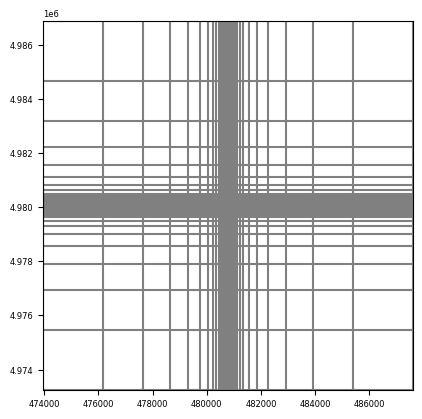

In [104]:
model_grid.plot()

In [105]:
model_grid.extent

(473965.4865398407, 487610.5134601593, 4973237.486539841, 4986882.513460159)

# use this below to correct the coordinates of pp in the df before adding parameters

In [109]:
model_grid.get_coords(0,0)

(473965.4865398407, 4973237.486539841)

Instantiate PstFrom

In [13]:
template_ws = os.path.join("PMW-6_template") #template directory (PstFrom working folder)
start_datetime = "08/29/2024"

#instantiate PstFrom
pf = pyemu.utils.PstFrom(
    original_d = tmp_d, #where the model is stored
    new_d = template_ws, #where the PEST template will be stored
    longnames = True, #for using PEST/PEST_HP
    spatial_reference = sr, #spatial reference from the model
    zero_based = False, #MODFLOW does not use zero based indices
    start_datetime = start_datetime, #for temporal correlation between parameters
    echo=True, 
    remove_existing=True, #remove existing files in the template directory
)

2025-10-15 10:56:13.129547 starting: opening PstFrom.log for logging
2025-10-15 10:56:13.131571 starting PstFrom process
2025-10-15 10:56:13.151015 starting: setting up dirs
2025-10-15 10:56:13.153030 starting: removing existing new_d 'PMW-6_template'
2025-10-15 10:56:13.292680 finished: removing existing new_d 'PMW-6_template' took: 0:00:00.139650
2025-10-15 10:56:13.292680 starting: copying original_d 'PMW-6_mf6' to new_d 'PMW-6_template'
2025-10-15 10:56:20.320353 finished: copying original_d 'PMW-6_mf6' to new_d 'PMW-6_template' took: 0:00:07.027673
2025-10-15 10:56:20.320353 finished: setting up dirs took: 0:00:07.169338


pf

In [14]:
import flopy.utils.binaryfile as bf
"""
Reads the MODFLOW binary heads file, extracts heads for specified
observation wells at desired times, interpolating between time steps
if necessary, and saves the data to heads.csv.
"""

model_name = "MLAC-model"

file_path = os.path.join(template_ws, 'well_location_and_times.csv')

# --- Load observation info from the CSV file ---
try:
    obs_df = pd.read_csv(file_path)

except FileNotFoundError:
    raise FileNotFoundError("well_locations.csv not found. Did you run create_model.py?")

# Check if the .hds file exists before attempting to read
hds_filepath = os.path.join(template_ws, f'{model_name}.hds')
if not os.path.exists(hds_filepath):
    raise FileNotFoundError(f"Binary heads file not found: {hds_filepath}")

hds_file = bf.HeadFile(hds_filepath)
model_output_times = np.array(hds_file.get_times())

# Get the unique well names and locations
well_locations = obs_df[['well_name', 'layer', 'row', 'col']].drop_duplicates()

# Prepare results storage
interpolated_results = []

for index, obs in obs_df.iterrows():
    well_name = obs['well_name']
    layer, row, col = obs['layer'], obs['row'], obs['col']
    target_time = obs['time']

    # Find the time steps in the model output that bracket the target_time
    # Use np.searchsorted for efficient finding of insertion points
    idx = np.searchsorted(model_output_times, target_time)

    # Handle edge cases: target_time is before the first or after the last model output time
    if idx == 0:
        # Target time is at or before the first model output time.
        # Use the first time step's head.
        # You might want to raise a warning or handle this differently (e.g., extrapolation if allowed).
        t1 = model_output_times[0]
        heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
        interpolated_head = heads_data_t1
        print(f"Warning: Target time {target_time} is before or at first model time {t1}. Using head at {t1}.")

    elif idx == len(model_output_times):
        # Target time is at or after the last model output time.
        # Use the last time step's head.
        # You might want to raise a warning or handle this differently.
        t1 = model_output_times[-1]
        heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
        interpolated_head = heads_data_t1
        print(f"Warning: Target time {target_time} is at or after last model time {t1}. Using head at {t1}.")

    else:
        # Target time is between two model output times or exactly at one.
        t1 = model_output_times[idx - 1]
        t2 = model_output_times[idx]

        if target_time == t1:
            # Exact match for the lower bound
            heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
            interpolated_head = heads_data_t1
        elif target_time == t2:
            # Exact match for the upper bound
            heads_data_t2 = hds_file.get_data(totim=t2)[layer, row, col]
            interpolated_head = heads_data_t2
        else:
            # Interpolate between t1 and t2
            heads_data_t1 = hds_file.get_data(totim=t1)[layer, row, col]
            heads_data_t2 = hds_file.get_data(totim=t2)[layer, row, col]

            # Linear interpolation formula
            interpolated_head = heads_data_t1 + (heads_data_t2 - heads_data_t1) * \
                                (target_time - t1) / (t2 - t1)
    
    interpolated_results.append({
        'time': target_time,
        'well_name': f'HEAD_{well_name}',
        'head': interpolated_head
    })

# Create and pivot the DataFrame
results_df = pd.DataFrame(interpolated_results)

# Pivot the data to have columns for each well name
output_df = results_df.pivot(index='time', columns='well_name', values='head')

# Sort by time, reset index for clean CSV, and ensure consistent output column order
output_df = output_df.sort_index().reset_index()

desired_order = ['time', 'HEAD_PW-1', 'HEAD_PMW-3', 'HEAD_PMW-10', 'HEAD_PMW-14',
                    'HEAD_PW-2', 'HEAD_PMW-9', 'HEAD_PZ-1', 'HEAD_PMW-4', 'HEAD_PMW-5',
                    'HEAD_OW24P', 'HEAD_OW23P', 'HEAD_OW17P']

# Select the columns in the specified order
# Note: If a column is in desired_order but not in output_df, it will be added as NaN.
# If a column is in output_df but not in desired_order, it will be dropped.
try:
    output_df = output_df[desired_order]
except KeyError as e:
    print(f"Warning: A column was not found during reordering: {e}")
    # Continue saving, but without the specified order if it fails

# Write to CSV
output_df.to_csv(os.path.join(template_ws, 'heads.csv'), index=False, float_format='%.16E')
print("heads.csv created with interpolated head data at specified times.")

heads.csv created with interpolated head data at specified times.


Checking data from MODFLOW

In [15]:
#checking the output csv files
for i in [gwf.obs]: 
    print(i.output.obs_names)

['heads.csv']


taking a look at the data file

In [16]:
df_modflow = pd.read_csv(os.path.join(template_ws, "heads.csv"), index_col=0)
df_modflow.head()

,HEAD_PW-1,HEAD_PMW-3,HEAD_PMW-10,HEAD_PMW-14,HEAD_PW-2,HEAD_PMW-9,HEAD_PZ-1,HEAD_PMW-4,HEAD_PMW-5,HEAD_OW24P,HEAD_OW23P,HEAD_OW17P
time,,,,,,,,,,,,
0.010417,0.020916,0.082986,0.099070,0.067635,0.077078,0.019033,0.045098,0.009717,0.026818,0.026691,0.110870,0.016515
0.020833,0.046839,0.123527,0.140921,0.106017,0.116659,0.044048,0.079158,0.028729,0.056122,0.056204,0.154632,0.040597
0.041667,0.081487,0.166799,0.184479,0.147901,0.159087,0.078432,0.118614,0.058585,0.092631,0.092736,0.199044,0.074118
0.062500,0.103825,0.192060,0.209663,0.172646,0.183869,0.100882,0.142682,0.079221,0.115362,0.114763,0.224219,0.095499


Taking a look at the field data

In [17]:
df_field = pd.read_csv("../../../data/PMW-6_t.csv", index_col=0)
df_field.head()

,HEAD_PW-1,HEAD_PMW-3,HEAD_PMW-10,HEAD_PMW-14,HEAD_PW-2,HEAD_PMW-9,HEAD_PZ-1,HEAD_PMW-4,HEAD_PMW-5,HEAD_OW24P,HEAD_OW23P,HEAD_OW17P
time,,,,,,,,,,,,
0.010417,0.009313,0.139853,0.005000,0.110165,0.00136,0.000,0.019109,-0.002393,0.006000,0.003426,0.021026,0.005726
0.020833,0.035997,0.203853,0.028999,0.180839,-0.00022,-0.001,0.063277,0.005620,0.030998,0.009688,0.045382,0.016650
0.041667,0.123661,0.282903,0.109995,0.260987,-0.00391,0.001,0.149909,0.025665,0.096995,0.013416,0.075830,0.033832
0.062500,0.184743,0.329537,0.170992,0.307138,0.00139,0.003,0.197710,0.045378,0.147993,0.025560,0.094278,0.050680


Both have the same order of wells

In [18]:
df_modflow.columns.values == df_field.columns.values

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

copying over the field data to our template folder. starting heads.csv will be the field data that will be used to add observation data in the PEST control file. during the PEST iterations, MODFLOW + processing code will overwrite this file with the current iteration simulation output. 

In [19]:
shutil.copy2(
    src="../../../data/PMW-6_t.csv",
    dst=os.path.join(template_ws, "heads.csv")
)

shutil.copy(
    src="../../../data/PMW-6_t.csv",
    dst=os.path.join(template_ws, "PMW-6_t.csv")
)

'PMW-6_template\\PMW-6_t.csv'

Adding field observation to pst

In [20]:
hds_df = pf.add_observations(
    "heads.csv", #data file to read
    insfile="heads.csv.ins", #instruction file name
    index_cols="time", #column header to use as index
    use_cols=list(df_field.columns.values), #name of columns that includes observation values
    #prefix="hds" #prefix to all observation names
    #obsnam_dict={"head_pw1": "pw1"}
)

2025-10-15 10:56:49.034335 starting: adding observations from output file heads.csv
2025-10-15 10:56:49.037757 starting: adding observations from tabular output file '['heads.csv']'
2025-10-15 10:56:49.037757 starting: reading list-style file: PMW-6_template\heads.csv
2025-10-15 10:56:49.067840 finished: reading list-style file: PMW-6_template\heads.csv took: 0:00:00.030083
2025-10-15 10:56:49.095249 starting: building insfile for tabular output file heads.csv
2025-10-15 10:56:49.137421 finished: building insfile for tabular output file heads.csv took: 0:00:00.042172
2025-10-15 10:56:49.143272 starting: adding observation from instruction file 'PMW-6_template\heads.csv.ins'
2025-10-15 10:56:49.222634 finished: adding observation from instruction file 'PMW-6_template\heads.csv.ins' took: 0:00:00.079362
2025-10-15 10:56:49.228372 finished: adding observations from tabular output file '['heads.csv']' took: 0:00:00.190615
2025-10-15 10:56:49.228372 finished: adding observations from output

In [21]:
hds_df.head()

,obsnme,obsval,weight,obgnme
oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.010417,0.005726,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p
oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.020833,0.016650,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p
oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.041667,0.033832,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p
oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.0625,0.050680,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p
oname:heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,oname:heads.csv_otype:lst_usecol:head_ow23p_time:0.010417,0.021026,1.0,oname:heads.csv_otype:lst_usecol:head_ow23p


instruction  file has been created in the template folder

In [22]:
[f for f in os.listdir(template_ws) if f.endswith(".ins")]

['heads.csv.ins']

Currently MODFLOW model has no idomain which will be used to inactivate some cells above the below BPP to simulate the packer. Since the current model only has 3 layers, I am not inactivating it yet, so we can collect data above the BPP

In [23]:
#get the IDOMAIN array
ib = gwf.dis.idomain.array[0]

plt.imshow(ib)
plt.colorbar()

TypeError: 'NoneType' object is not subscriptable

Geostatistical structures

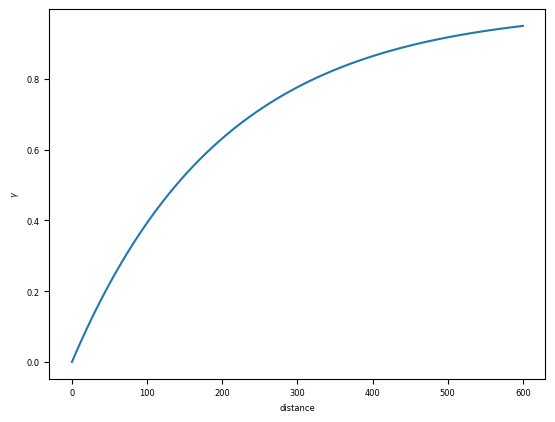

In [24]:
#exponential variogram for spatially varying parameters
v_pp = pyemu.geostats.ExpVario(
    contribution=1.0, #sill
    a=200, #range of correlation in meters
    anisotropy=1.0, 
    bearing=0.0, #angle in degrees East to North  corresponding to anisotropy ellipse
)

#geostatiscal structure for spatially varying parameters
pp_gs = pyemu.geostats.GeoStruct(variograms=v_pp, transform='log')

#plotting
ax = pp_gs.plot()

Adding the parameters to layer 0: pilot points grid

In [25]:
#starting by getting array of idomain for the layer 0. this contain information of inactive cell to avoid placing pilot points
ib0 = gwf.dis.idomain.array[0]
plt.imshow(ib)

TypeError: 'NoneType' object is not subscriptable

In [26]:
prefix_dict = {0: ['hk1']}
df_pp = pyemu.pp_utils.setup_pilotpoints_grid(
    sr=sr, #model spatial reference
    prefix_dict=prefix_dict, 
    pp_dir=template_ws, 
    tpl_dir=template_ws, 
    every_n_cell=70, 
    shapename=os.path.join(template_ws, 'pp_lyr1.shp')
)

ibound not passed, using array of ones


In [27]:
df_pp.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,tpl_filename,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale
0,pp_0000,480629.50046,4.980219e+06,1,1.0,0,35,35,hk1_i:35_j:35_zone:1,~ hk1_i:35_j:35_zone:1 ~,PMW-6_template\hk1pp.dat.tpl,PMW-6_template\hk1pp.dat,hk1,1,0.0,factor,1.100000e-10,log,1.100000e+10,1.0
1,pp_0001,480699.50046,4.980219e+06,1,1.0,0,35,105,hk1_i:35_j:105_zone:1,~ hk1_i:35_j:105_zone:1 ~,PMW-6_template\hk1pp.dat.tpl,PMW-6_template\hk1pp.dat,hk1,1,0.0,factor,1.100000e-10,log,1.100000e+10,1.0
2,pp_0002,480769.50046,4.980219e+06,1,1.0,0,35,175,hk1_i:35_j:175_zone:1,~ hk1_i:35_j:175_zone:1 ~,PMW-6_template\hk1pp.dat.tpl,PMW-6_template\hk1pp.dat,hk1,1,0.0,factor,1.100000e-10,log,1.100000e+10,1.0
3,pp_0003,480839.50046,4.980219e+06,1,1.0,0,35,245,hk1_i:35_j:245_zone:1,~ hk1_i:35_j:245_zone:1 ~,PMW-6_template\hk1pp.dat.tpl,PMW-6_template\hk1pp.dat,hk1,1,0.0,factor,1.100000e-10,log,1.100000e+10,1.0
4,pp_0004,480909.50046,4.980219e+06,1,1.0,0,35,315,hk1_i:35_j:315_zone:1,~ hk1_i:35_j:315_zone:1 ~,PMW-6_template\hk1pp.dat.tpl,PMW-6_template\hk1pp.dat,hk1,1,0.0,factor,1.100000e-10,log,1.100000e+10,1.0


In [30]:
pp1_file = os.path.join(template_ws, "hk1pp.dat")
assert os.path.exists(pp1_file)

In [32]:
df_pp1 = pf.add_parameters(
    'k_layer1.txt', #check that
    par_type='pilotpoints', 
    par_name_base="k_layer1", 
    #pargp="hk0", 
    #zone_array=ib, #to be added when inactivating some cells
    geostruct=pp_gs, #geostructure of the pilot points (prior?)
    lower_bound=0.01, upper_bound=1000, 
    ult_ubound=1000, ult_lbound=0.001,
    pp_space=df_pp
)

2025-10-15 10:59:42.532043 transform was not passed, setting default tranform to 'log'
2025-10-15 10:59:42.533042 starting: adding pilotpoints type m style parameters for file(s) ['k_layer1.txt']
2025-10-15 10:59:42.533042 starting: using geostruct:name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:200.0,anisotropy:1.0,bearing:0.0

2025-10-15 10:59:42.533042 starting: loading array PMW-6_template\k_layer1.txt
2025-10-15 10:59:42.605455 finished: loading array PMW-6_template\k_layer1.txt took: 0:00:00.072413
2025-10-15 10:59:42.605455 loaded array 'PMW-6_mf6\k_layer1.txt' of shape (388, 388)
2025-10-15 10:59:42.720985 starting: writing array-style template file 'PMW-6_template\k_layer1_inst0_pilotpoints.csv.tpl'
2025-10-15 10:59:42.720985 starting: setting up pilot point parameters
2025-10-15 10:59:42.720985 No spatial reference (containing cell spacing) passed.
2025-10-15 10:59:42.720985 OK - using spatial reference in parent object.
2025-10-15 10:59:42.733991 25 pilot po

In [33]:
len(df_pp)

25

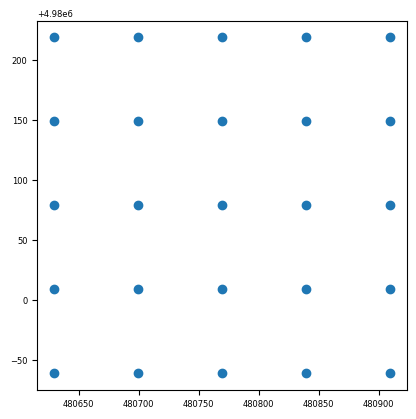

In [36]:
fig, ax = plt.subplots()
ax.set_aspect("equal")
#ax.pcolormesh(sr.xcentergrid, sr.ycentergrid, ib)
ax.scatter(df_pp1.x, df_pp1.y)

adding parameter to layer 2 (BPP): constant K for now

In [37]:
df_cst = pf.add_parameters(
    "k_layer2.txt", 
    par_type='constant', 
    par_name_base="k_layer2", 
    pargp="k_layer2", 
    initial_value=gwf.npf.k.array[1][0][0],
    lower_bound=0.01, upper_bound=1000, 
    ult_ubound=1000, ult_lbound=0.001, 
    )

2025-10-15 11:16:05.014906 transform was not passed, setting default tranform to 'log'
2025-10-15 11:16:05.015691 starting: adding constant type m style parameters for file(s) ['k_layer2.txt']
2025-10-15 11:16:05.015691 starting: loading array PMW-6_template\k_layer2.txt
2025-10-15 11:16:05.061276 finished: loading array PMW-6_template\k_layer2.txt took: 0:00:00.045585
2025-10-15 11:16:05.061276 loaded array 'PMW-6_mf6\k_layer2.txt' of shape (388, 388)
2025-10-15 11:16:05.338150 starting: writing array-style template file 'PMW-6_template\k_layer2_inst0_constant.csv.tpl'
2025-10-15 11:16:05.340147 starting: writing template file PMW-6_template\k_layer2_inst0_constant.csv.tpl for ['k_layer2_inst:0']
2025-10-15 11:16:06.932474 finished: writing template file PMW-6_template\k_layer2_inst0_constant.csv.tpl for ['k_layer2_inst:0'] took: 0:00:01.592327
2025-10-15 11:16:06.938601 starting: writing array-based template file 'PMW-6_template\k_layer2_inst0_constant.csv.tpl'
2025-10-15 11:16:06.98

Adding parameter to layer 3: pilot points

In [38]:
#starting by getting array of idomain for the layer 0. this contain information of inactive cell to avoid placing pilot points
ib3 = gwf.dis.idomain.array[2]
plt.imshow(ib3)

TypeError: 'NoneType' object is not subscriptable

In [39]:
prefix_dict = {0: ['hk3']}
df_pp3 = pyemu.pp_utils.setup_pilotpoints_grid(
    sr=sr, #model spatial reference
    prefix_dict=prefix_dict, 
    pp_dir=template_ws, 
    tpl_dir=template_ws, 
    every_n_cell=70, 
    shapename=os.path.join(template_ws, 'pp_lyr3.shp')
)

ibound not passed, using array of ones


In [40]:
df_pp3.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,tpl_filename,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale
0,pp_0000,480629.50046,4.980219e+06,1,1.0,0,35,35,hk3_i:35_j:35_zone:1,~ hk3_i:35_j:35_zone:1 ~,PMW-6_template\hk3pp.dat.tpl,PMW-6_template\hk3pp.dat,hk3,1,0.0,factor,1.100000e-10,log,1.100000e+10,1.0
1,pp_0001,480699.50046,4.980219e+06,1,1.0,0,35,105,hk3_i:35_j:105_zone:1,~ hk3_i:35_j:105_zone:1 ~,PMW-6_template\hk3pp.dat.tpl,PMW-6_template\hk3pp.dat,hk3,1,0.0,factor,1.100000e-10,log,1.100000e+10,1.0
2,pp_0002,480769.50046,4.980219e+06,1,1.0,0,35,175,hk3_i:35_j:175_zone:1,~ hk3_i:35_j:175_zone:1 ~,PMW-6_template\hk3pp.dat.tpl,PMW-6_template\hk3pp.dat,hk3,1,0.0,factor,1.100000e-10,log,1.100000e+10,1.0
3,pp_0003,480839.50046,4.980219e+06,1,1.0,0,35,245,hk3_i:35_j:245_zone:1,~ hk3_i:35_j:245_zone:1 ~,PMW-6_template\hk3pp.dat.tpl,PMW-6_template\hk3pp.dat,hk3,1,0.0,factor,1.100000e-10,log,1.100000e+10,1.0
4,pp_0004,480909.50046,4.980219e+06,1,1.0,0,35,315,hk3_i:35_j:315_zone:1,~ hk3_i:35_j:315_zone:1 ~,PMW-6_template\hk3pp.dat.tpl,PMW-6_template\hk3pp.dat,hk3,1,0.0,factor,1.100000e-10,log,1.100000e+10,1.0


In [41]:
df_pp3['k'] = 2
df_pp3.head()

,name,x,y,zone,parval1,k,i,j,parnme,tpl,tpl_filename,pp_filename,pargp,dercom,offset,parchglim,parlbnd,partrans,parubnd,scale
0,pp_0000,480629.50046,4.980219e+06,1,1.0,2,35,35,hk3_i:35_j:35_zone:1,~ hk3_i:35_j:35_zone:1 ~,PMW-6_template\hk3pp.dat.tpl,PMW-6_template\hk3pp.dat,hk3,1,0.0,factor,1.100000e-10,log,1.100000e+10,1.0
1,pp_0001,480699.50046,4.980219e+06,1,1.0,2,35,105,hk3_i:35_j:105_zone:1,~ hk3_i:35_j:105_zone:1 ~,PMW-6_template\hk3pp.dat.tpl,PMW-6_template\hk3pp.dat,hk3,1,0.0,factor,1.100000e-10,log,1.100000e+10,1.0
2,pp_0002,480769.50046,4.980219e+06,1,1.0,2,35,175,hk3_i:35_j:175_zone:1,~ hk3_i:35_j:175_zone:1 ~,PMW-6_template\hk3pp.dat.tpl,PMW-6_template\hk3pp.dat,hk3,1,0.0,factor,1.100000e-10,log,1.100000e+10,1.0
3,pp_0003,480839.50046,4.980219e+06,1,1.0,2,35,245,hk3_i:35_j:245_zone:1,~ hk3_i:35_j:245_zone:1 ~,PMW-6_template\hk3pp.dat.tpl,PMW-6_template\hk3pp.dat,hk3,1,0.0,factor,1.100000e-10,log,1.100000e+10,1.0
4,pp_0004,480909.50046,4.980219e+06,1,1.0,2,35,315,hk3_i:35_j:315_zone:1,~ hk3_i:35_j:315_zone:1 ~,PMW-6_template\hk3pp.dat.tpl,PMW-6_template\hk3pp.dat,hk3,1,0.0,factor,1.100000e-10,log,1.100000e+10,1.0


In [42]:
pp3_file = os.path.join(template_ws, "hk3pp.dat")
assert os.path.exists(pp3_file)

In [43]:
df_pp1 = pf.add_parameters(
    'k_layer3.txt', #check that
    par_type='pilotpoints', 
    par_name_base="k_layer3", 
    #pargp="hk0", 
    #zone_array=ib, #to be added when inactivating some cells
    
    geostruct=pp_gs, #geostructure of the pilot points (prior?) 
    #USING THE SAME STRUCTURE AS LAYER 1 (ABOVE BPP)

    lower_bound=0.01, upper_bound=1000, 
    ult_ubound=1000, ult_lbound=0.001,
    pp_space=df_pp3
)

2025-10-15 11:23:19.203794 transform was not passed, setting default tranform to 'log'
2025-10-15 11:23:19.203794 starting: adding pilotpoints type m style parameters for file(s) ['k_layer3.txt']
2025-10-15 11:23:19.203794 finished: using geostruct:name:struct1,nugget:0.0,structures:
name:var1,contribution:1.0,a:200.0,anisotropy:1.0,bearing:0.0
 took: 0:23:36.670752
2025-10-15 11:23:19.203794 starting: loading array PMW-6_template\k_layer3.txt
2025-10-15 11:23:19.323450 finished: loading array PMW-6_template\k_layer3.txt took: 0:00:00.119656
2025-10-15 11:23:19.323450 loaded array 'PMW-6_mf6\k_layer3.txt' of shape (388, 388)
2025-10-15 11:23:19.390980 starting: writing array-style template file 'PMW-6_template\k_layer3_inst0_pilotpoints.csv.tpl'
2025-10-15 11:23:19.390980 starting: setting up pilot point parameters
2025-10-15 11:23:19.390980 No spatial reference (containing cell spacing) passed.
2025-10-15 11:23:19.390980 OK - using spatial reference in parent object.
2025-10-15 11:23:

building pst

In [44]:
pst = pf.build_pst()

noptmax:0, npar_adj:51, nnz_obs:48


checking parameter groups and data

In [45]:
pst.parameter_groups

,pargpnme,inctyp,derinc,derinclb,forcen,derincmul,dermthd,splitthresh,splitreldiff,splitaction
pargpnme,,,,,,,,,,
k_layer1_inst:0,k_layer1_inst:0,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
k_layer3_inst:0,k_layer3_inst:0,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller
k_layer2,k_layer2,relative,0.01,0.0,switch,2.0,parabolic,0.00001,0.5,smaller


In [46]:
pst.parameter_data

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,i,inst,j,pname,pstyle,ptype,zone
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,35,0,35,k,m,pp,1
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,35,0,105,k,m,pp,1
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,35,0,175,k,m,pp,1
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,35,0,245,k,m,pp,1
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,35,0,315,k,m,pp,1
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:35_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:35_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,105,0,35,k,m,pp,1
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:105_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:105_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,105,0,105,k,m,pp,1
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:175_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:175_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,105,0,175,k,m,pp,1
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:245_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:245_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,105,0,245,k,m,pp,1
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:315_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:315_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,105,0,315,k,m,pp,1


adding mf6 executable code in the PEST running script

In [47]:
pf.mod_sys_cmds.append("mf6") #do this only once
pf.mod_sys_cmds

['mf6']

adding the processing MODFLOW output in the PEST running script. 

This processing script reads the MODFLOW simulation output (heads for all well in all simulation time steps), and sample heads only for desired times (i.e. times that we have field data) using interpolation, then overwrites the heads.csv (MODFLOW output) used to compared with the observation data added to the PEST control file.

In [48]:
pf.add_py_function("helpers.py","process_heads_csv()",is_pre_cmd=False)

building pst and printing the PEST running script

In [49]:
pst = pf.build_pst()

_ = [print(line.rstrip()) for line in open(os.path.join(template_ws,"forward_run.py"))]

noptmax:0, npar_adj:51, nnz_obs:48
2025-10-15 11:26:14.236429 forward_run line:pyemu.os_utils.run(r'mf6')

import os
import multiprocessing as mp
import numpy as np
import pandas as pd
import pyemu

# function added thru PstFrom.add_py_function()
def process_heads_csv(model_name="MLAC-model"):
    import flopy.utils.binaryfile as bf
    """
    Reads the MODFLOW binary heads file, extracts heads for specified
    observation wells at desired times, interpolating between time steps
    if necessary, and saves the data to heads.csv.
    """

    model_ws = "."

    file_path = os.path.join(model_ws, 'well_location_and_times.csv')

    # --- Load observation info from the CSV file ---
    try:
        obs_df = pd.read_csv(file_path)

    except FileNotFoundError:
        raise FileNotFoundError("well_locations.csv not found. Did you run create_model.py?")

    # Check if the .hds file exists before attempting to read
    hds_filepath = os.path.join(model_ws, f'{model_name}.hds')
    if no

updating the maximum number of PEST iteration

In [50]:
pst.control_data.noptmax = 3
pst.control_data.noptmax

3

In [51]:
print(f'there are {pst.nobs} field observation')

there are 48 field observation


changing observation names to meet the PEST version 1 character limit

In [52]:
print('current observation names:')
pst.obs_names

current observation names:


['oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.010417',
 'oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.020833',
 'oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.041667',
 'oname:heads.csv_otype:lst_usecol:head_ow17p_time:0.0625',
 'oname:heads.csv_otype:lst_usecol:head_ow23p_time:0.010417',
 'oname:heads.csv_otype:lst_usecol:head_ow23p_time:0.020833',
 'oname:heads.csv_otype:lst_usecol:head_ow23p_time:0.041667',
 'oname:heads.csv_otype:lst_usecol:head_ow23p_time:0.0625',
 'oname:heads.csv_otype:lst_usecol:head_ow24p_time:0.010417',
 'oname:heads.csv_otype:lst_usecol:head_ow24p_time:0.020833',
 'oname:heads.csv_otype:lst_usecol:head_ow24p_time:0.041667',
 'oname:heads.csv_otype:lst_usecol:head_ow24p_time:0.0625',
 'oname:heads.csv_otype:lst_usecol:head_pmw-10_time:0.010417',
 'oname:heads.csv_otype:lst_usecol:head_pmw-10_time:0.020833',
 'oname:heads.csv_otype:lst_usecol:head_pmw-10_time:0.041667',
 'oname:heads.csv_otype:lst_usecol:head_pmw-10_time:0.0625',
 'oname:head

In [53]:
new_obs_names_dict = {name: name[38:] for name in pst.obs_names}
pst.rename_observations(new_obs_names_dict,
                        pst_path=template_ws
                        )

In [54]:
print('new observation names:')
pst.obs_names

new observation names:


['ow17p_time:0.010417',
 'ow17p_time:0.020833',
 'ow17p_time:0.041667',
 'ow17p_time:0.0625',
 'ow23p_time:0.010417',
 'ow23p_time:0.020833',
 'ow23p_time:0.041667',
 'ow23p_time:0.0625',
 'ow24p_time:0.010417',
 'ow24p_time:0.020833',
 'ow24p_time:0.041667',
 'ow24p_time:0.0625',
 'pmw-10_time:0.010417',
 'pmw-10_time:0.020833',
 'pmw-10_time:0.041667',
 'pmw-10_time:0.0625',
 'pmw-14_time:0.010417',
 'pmw-14_time:0.020833',
 'pmw-14_time:0.041667',
 'pmw-14_time:0.0625',
 'pmw-3_time:0.010417',
 'pmw-3_time:0.020833',
 'pmw-3_time:0.041667',
 'pmw-3_time:0.0625',
 'pmw-4_time:0.010417',
 'pmw-4_time:0.020833',
 'pmw-4_time:0.041667',
 'pmw-4_time:0.0625',
 'pmw-5_time:0.010417',
 'pmw-5_time:0.020833',
 'pmw-5_time:0.041667',
 'pmw-5_time:0.0625',
 'pmw-9_time:0.010417',
 'pmw-9_time:0.020833',
 'pmw-9_time:0.041667',
 'pmw-9_time:0.0625',
 'pw-1_time:0.010417',
 'pw-1_time:0.020833',
 'pw-1_time:0.041667',
 'pw-1_time:0.0625',
 'pw-2_time:0.010417',
 'pw-2_time:0.020833',
 'pw-2_tim

Changing observation group names

Each observation group correspond to a well in a injection test. So observation in the same well (and zone) during the same injection test are grouped together

In [55]:
print('old observation group names:')
pst.obs_groups

old observation group names:


['oname:heads.csv_otype:lst_usecol:head_ow17p',
 'oname:heads.csv_otype:lst_usecol:head_ow23p',
 'oname:heads.csv_otype:lst_usecol:head_ow24p',
 'oname:heads.csv_otype:lst_usecol:head_pmw-10',
 'oname:heads.csv_otype:lst_usecol:head_pmw-14',
 'oname:heads.csv_otype:lst_usecol:head_pmw-3',
 'oname:heads.csv_otype:lst_usecol:head_pmw-4',
 'oname:heads.csv_otype:lst_usecol:head_pmw-5',
 'oname:heads.csv_otype:lst_usecol:head_pmw-9',
 'oname:heads.csv_otype:lst_usecol:head_pw-1',
 'oname:heads.csv_otype:lst_usecol:head_pw-2',
 'oname:heads.csv_otype:lst_usecol:head_pz-1']

In [56]:
pst.observation_data.head()

,obsnme,obsval,weight,obgnme,oname,otype,time,usecol
ow17p_time:0.010417,ow17p_time:0.010417,0.005726,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p,heads.csv,lst,0.010417,head
ow17p_time:0.020833,ow17p_time:0.020833,0.016650,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p,heads.csv,lst,0.020833,head
ow17p_time:0.041667,ow17p_time:0.041667,0.033832,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p,heads.csv,lst,0.041667,head
ow17p_time:0.0625,ow17p_time:0.0625,0.050680,1.0,oname:heads.csv_otype:lst_usecol:head_ow17p,heads.csv,lst,0.0625,head
ow23p_time:0.010417,ow23p_time:0.010417,0.021026,1.0,oname:heads.csv_otype:lst_usecol:head_ow23p,heads.csv,lst,0.010417,head


updated names

In [57]:
group_mapping = {old: f'inj_pmw-6_{old[33:]}' for old in pst.obs_groups}

pst.observation_data['obgnme'] = pst.observation_data['obgnme'].map(group_mapping)
pst.observation_data.head()

,obsnme,obsval,weight,obgnme,oname,otype,time,usecol
ow17p_time:0.010417,ow17p_time:0.010417,0.005726,1.0,inj_pmw-6_head_ow17p,heads.csv,lst,0.010417,head
ow17p_time:0.020833,ow17p_time:0.020833,0.016650,1.0,inj_pmw-6_head_ow17p,heads.csv,lst,0.020833,head
ow17p_time:0.041667,ow17p_time:0.041667,0.033832,1.0,inj_pmw-6_head_ow17p,heads.csv,lst,0.041667,head
ow17p_time:0.0625,ow17p_time:0.0625,0.050680,1.0,inj_pmw-6_head_ow17p,heads.csv,lst,0.0625,head
ow23p_time:0.010417,ow23p_time:0.010417,0.021026,1.0,inj_pmw-6_head_ow23p,heads.csv,lst,0.010417,head


taking a look at the parameter data and renaming it

In [58]:
#renaming parameters
pst.parameter_data

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,i,inst,j,pname,pstyle,ptype,zone
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,35,0,35,k,m,pp,1
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,35,0,105,k,m,pp,1
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,35,0,175,k,m,pp,1
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,35,0,245,k,m,pp,1
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,35,0,315,k,m,pp,1
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:35_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:35_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,105,0,35,k,m,pp,1
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:105_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:105_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,105,0,105,k,m,pp,1
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:175_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:175_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,105,0,175,k,m,pp,1
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:245_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:245_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,105,0,245,k,m,pp,1
pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:315_zone:1,pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:315_zone:1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,105,0,315,k,m,pp,1


In [69]:
import re
new_par_names_dict = {pst.par_names[i]:f"{pst.par_names[i].split('_')[1]}_{re.split(r'[_:]+', pst.par_names[i])[6]}_{i}" for i in range(len(pst.par_names))}
print('old and new parameter names: ')
new_par_names_dict

old and new parameter names: 


{'pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:35_zone:1': 'layer1_pp_0',
 'pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:105_zone:1': 'layer1_pp_1',
 'pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:175_zone:1': 'layer1_pp_2',
 'pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:245_zone:1': 'layer1_pp_3',
 'pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:35_j:315_zone:1': 'layer1_pp_4',
 'pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:35_zone:1': 'layer1_pp_5',
 'pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:105_zone:1': 'layer1_pp_6',
 'pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:175_zone:1': 'layer1_pp_7',
 'pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:245_zone:1': 'layer1_pp_8',
 'pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:105_j:315_zone:1': 'layer1_pp_9',
 'pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:175_j:35_zone:1': 'layer1_pp_10',
 'pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:175_j:105_zone:1': 'layer1_pp_11',
 'pname:k_layer1_inst:0_ptype:pp_pstyle:m_i:175_j:175_zone:1': 'layer1

In [70]:
pst.rename_parameters(new_par_names_dict,
                        pst_path=template_ws
                        )
pst.parameter_data

,parnme,partrans,parchglim,parval1,parlbnd,parubnd,pargp,scale,offset,dercom,i,inst,j,pname,pstyle,ptype,zone
layer1_pp_0,layer1_pp_0,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,35,0,35,k,m,pp,1
layer1_pp_1,layer1_pp_1,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,35,0,105,k,m,pp,1
layer1_pp_2,layer1_pp_2,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,35,0,175,k,m,pp,1
layer1_pp_3,layer1_pp_3,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,35,0,245,k,m,pp,1
layer1_pp_4,layer1_pp_4,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,35,0,315,k,m,pp,1
layer1_pp_5,layer1_pp_5,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,105,0,35,k,m,pp,1
layer1_pp_6,layer1_pp_6,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,105,0,105,k,m,pp,1
layer1_pp_7,layer1_pp_7,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,105,0,175,k,m,pp,1
layer1_pp_8,layer1_pp_8,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,105,0,245,k,m,pp,1
layer1_pp_9,layer1_pp_9,log,factor,1.0000,0.01,1000.0,k_layer1_inst:0,1.0,0.0,1,105,0,315,k,m,pp,1


Checking input and output model files

In [71]:
pst.model_input_data

,pest_file,model_file
k_layer1_inst0pp.dat.tpl,k_layer1_inst0pp.dat.tpl,k_layer1_inst0pp.dat
k_layer2_inst0_constant.csv.tpl,k_layer2_inst0_constant.csv.tpl,mult\k_layer2_inst0_constant.csv
k_layer3_inst0pp.dat.tpl,k_layer3_inst0pp.dat.tpl,k_layer3_inst0pp.dat


In [72]:
pst.model_output_data

,pest_file,model_file
heads.csv.ins,heads.csv.ins,heads.csv


overwritting pst file

In [73]:
pst.write(os.path.join(template_ws, 'PMW-6_mf6.pst'),version=1)

noptmax:3, npar_adj:51, nnz_obs:48


Running PEST

In [74]:
pyemu.os_utils.run('pestpp-glm PMW-6_mf6.pst', cwd=template_ws, verbose=True)

run():pestpp-glm.exe PMW-6_mf6.pst


plotting results

In [75]:
df_obj = pd.read_csv(os.path.join(template_ws, "PMW-6_mf6.iobj"),index_col=0)
# echo out the dataframe
df_obj

,model_runs_completed,total_phi,measurement_phi,regularization_phi,inj_pmw-6_head_ow17p,inj_pmw-6_head_ow23p,inj_pmw-6_head_ow24p,inj_pmw-6_head_pmw-10,inj_pmw-6_head_pmw-14,inj_pmw-6_head_pmw-3,inj_pmw-6_head_pmw-4,inj_pmw-6_head_pmw-5,inj_pmw-6_head_pmw-9,inj_pmw-6_head_pw-1,inj_pmw-6_head_pw-2,inj_pmw-6_head_pz-1
iteration,,,,,,,,,,,,,,,,
0,0,0.296050,0.296050,0,0.004236,0.050746,0.016682,0.027745,0.038919,0.042901,0.002887,0.002182,0.017858,0.008669,0.078182,0.005041
1,67,0.279325,0.279325,0,0.003857,0.039286,0.015390,0.025120,0.038651,0.044174,0.003162,0.002361,0.018034,0.008414,0.075631,0.005244
2,136,0.243595,0.243595,0,0.002583,0.019651,0.012473,0.014663,0.047391,0.051919,0.003066,0.004690,0.012718,0.011645,0.052322,0.010476
3,208,0.186808,0.186808,0,0.000140,0.001166,0.002436,0.008935,0.049349,0.044570,0.001884,0.007843,0.002751,0.018894,0.028860,0.019981


array([<Axes: xlabel='iteration'>, <Axes: xlabel='iteration'>],
      dtype=object)

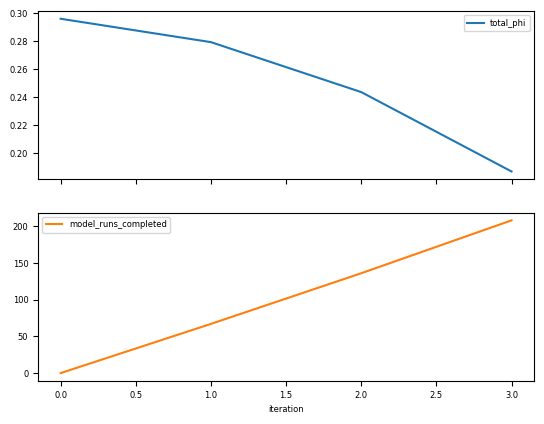

In [76]:
df_obj.loc[:,["total_phi","model_runs_completed"]].plot(subplots=True)

Estimated K values:

In [77]:
pst.parameter_data.parval1

layer1_pp_0     1.0000
layer1_pp_1     1.0000
layer1_pp_2     1.0000
layer1_pp_3     1.0000
layer1_pp_4     1.0000
layer1_pp_5     1.0000
layer1_pp_6     1.0000
layer1_pp_7     1.0000
layer1_pp_8     1.0000
layer1_pp_9     1.0000
layer1_pp_10    1.0000
layer1_pp_11    1.0000
layer1_pp_12    1.0000
layer1_pp_13    1.0000
layer1_pp_14    1.0000
layer1_pp_15    1.0000
layer1_pp_16    1.0000
layer1_pp_17    1.0000
layer1_pp_18    1.0000
layer1_pp_19    1.0000
layer1_pp_20    1.0000
layer1_pp_21    1.0000
layer1_pp_22    1.0000
layer1_pp_23    1.0000
layer1_pp_24    1.0000
layer2_cn_25    1.8157
layer3_pp_26    1.0000
layer3_pp_27    1.0000
layer3_pp_28    1.0000
layer3_pp_29    1.0000
layer3_pp_30    1.0000
layer3_pp_31    1.0000
layer3_pp_32    1.0000
layer3_pp_33    1.0000
layer3_pp_34    1.0000
layer3_pp_35    1.0000
layer3_pp_36    1.0000
layer3_pp_37    1.0000
layer3_pp_38    1.0000
layer3_pp_39    1.0000
layer3_pp_40    1.0000
layer3_pp_41    1.0000
layer3_pp_42    1.0000
layer3_pp_4

In [78]:
estimated_parameters = pst.parameter_data.copy()
10**(estimated_parameters.loc[estimated_parameters['partrans'] == 'log', 'parval1'])


layer1_pp_0     10.000000
layer1_pp_1     10.000000
layer1_pp_2     10.000000
layer1_pp_3     10.000000
layer1_pp_4     10.000000
layer1_pp_5     10.000000
layer1_pp_6     10.000000
layer1_pp_7     10.000000
layer1_pp_8     10.000000
layer1_pp_9     10.000000
layer1_pp_10    10.000000
layer1_pp_11    10.000000
layer1_pp_12    10.000000
layer1_pp_13    10.000000
layer1_pp_14    10.000000
layer1_pp_15    10.000000
layer1_pp_16    10.000000
layer1_pp_17    10.000000
layer1_pp_18    10.000000
layer1_pp_19    10.000000
layer1_pp_20    10.000000
layer1_pp_21    10.000000
layer1_pp_22    10.000000
layer1_pp_23    10.000000
layer1_pp_24    10.000000
layer2_cn_25    65.418412
layer3_pp_26    10.000000
layer3_pp_27    10.000000
layer3_pp_28    10.000000
layer3_pp_29    10.000000
layer3_pp_30    10.000000
layer3_pp_31    10.000000
layer3_pp_32    10.000000
layer3_pp_33    10.000000
layer3_pp_34    10.000000
layer3_pp_35    10.000000
layer3_pp_36    10.000000
layer3_pp_37    10.000000
layer3_pp_38

plotting head results

In [79]:
res_nz = pst.res.loc[pst.nnz_obs_names,:]
# display res_nz to understand what we are doing
res_nz.head(4)

,name,group,measured,modelled,residual,weight
name,,,,,,
ow17p_time:0.010417,ow17p_time:0.010417,inj_pmw-6_head_ow17p,0.005726,0.009281,-0.003554,1.0
ow17p_time:0.020833,ow17p_time:0.020833,inj_pmw-6_head_ow17p,0.016650,0.022761,-0.006111,1.0
ow17p_time:0.041667,ow17p_time:0.041667,inj_pmw-6_head_ow17p,0.033832,0.042459,-0.008627,1.0
ow17p_time:0.0625,ow17p_time:0.0625,inj_pmw-6_head_ow17p,0.050680,0.054581,-0.003901,1.0


<Figure size 800x1050 with 0 Axes>

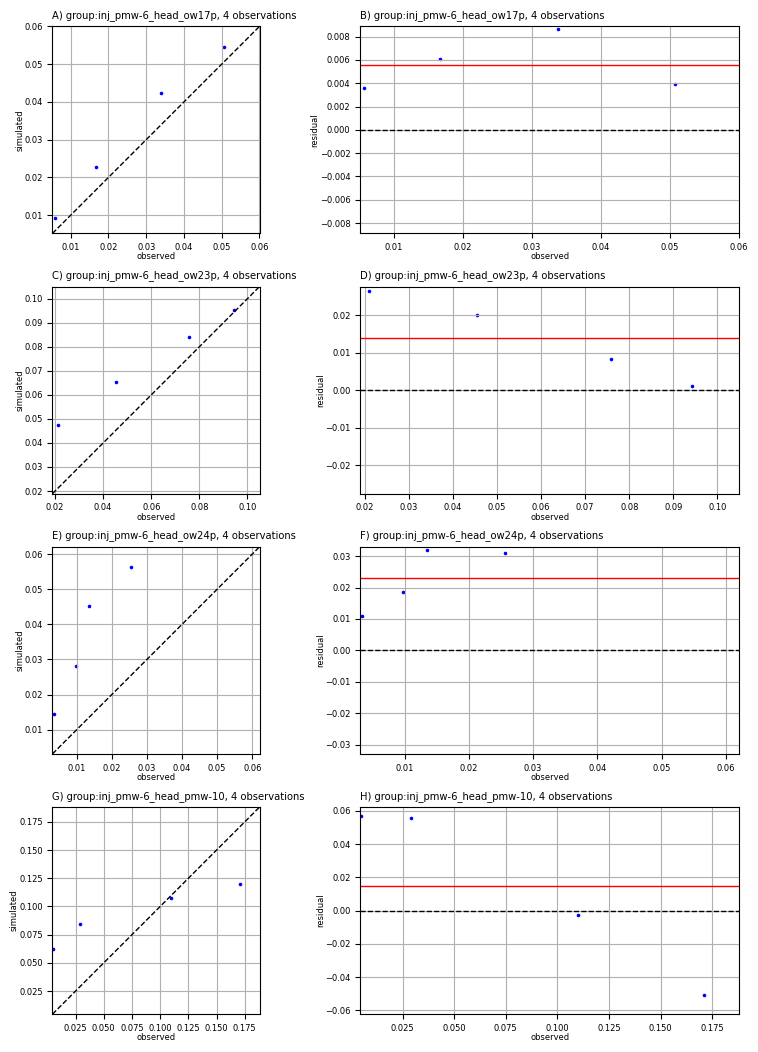

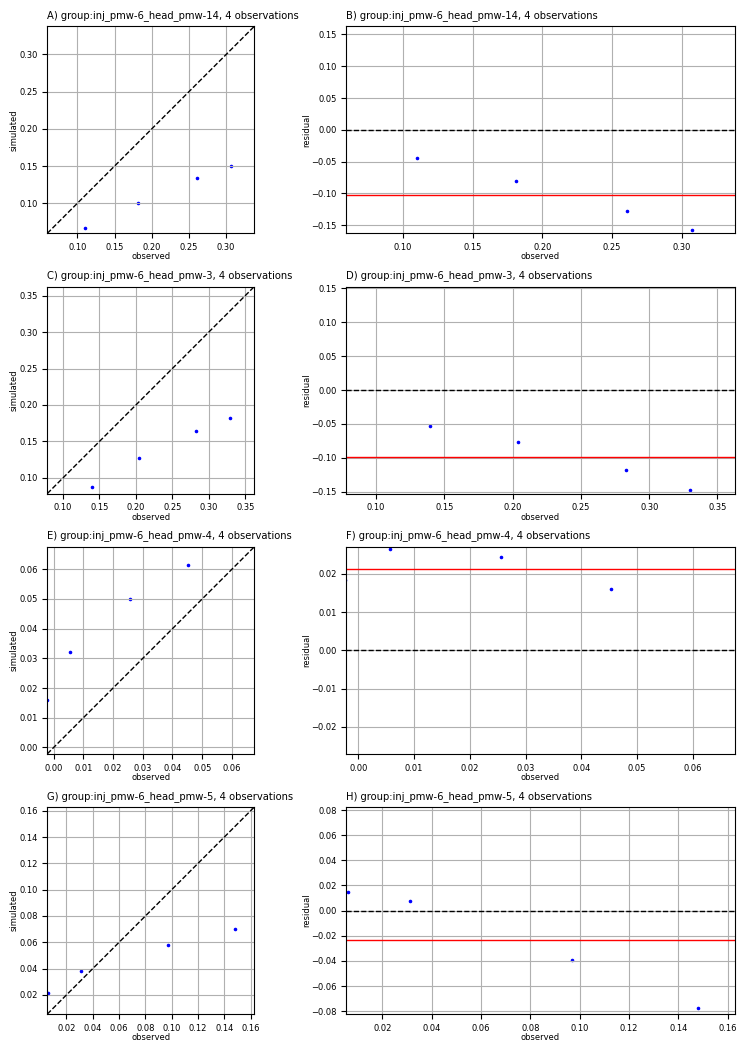

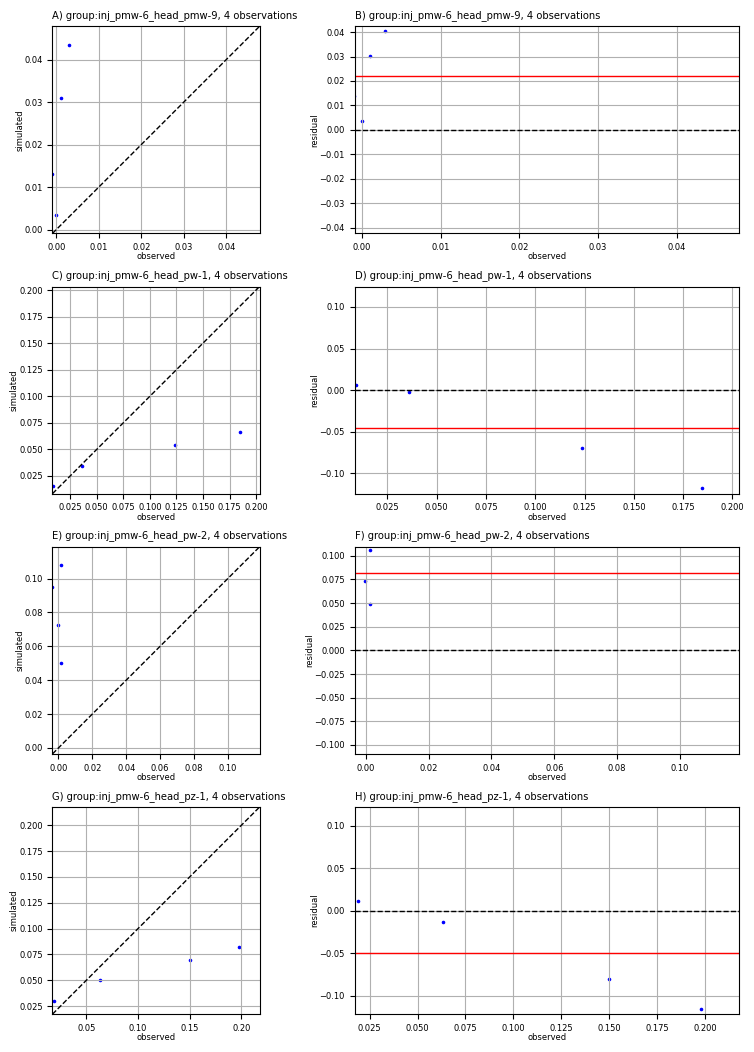

In [80]:
pyemu.plot_utils.res_1to1(pst);

plotting estimated K field

In [82]:
sim = flopy.mf6.MFSimulation.load(sim_ws=template_ws)
gwf = sim.get_model()

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package chd...
    loading package wel...
    loading package oc...
    loading package obs...
  loading solution package mlac-model...


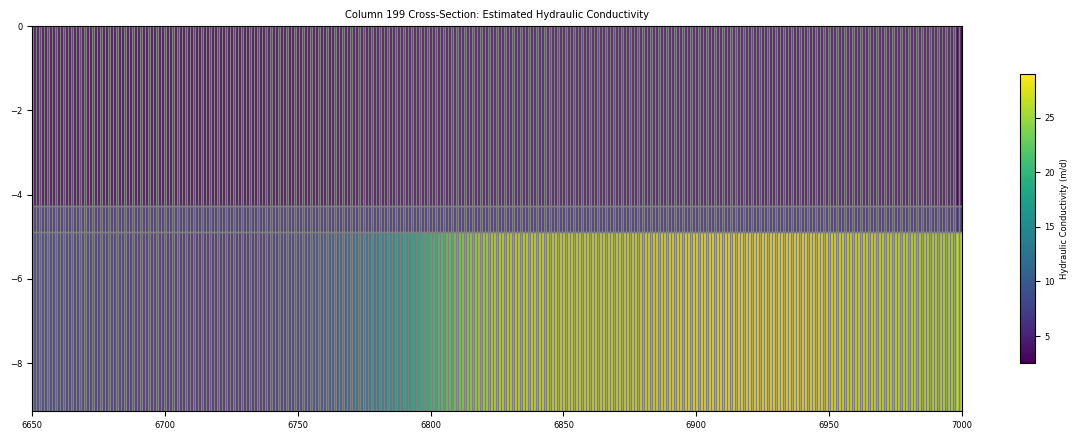

In [84]:
hk_array = gwf.npf.k.array

fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(1, 1, 1)

# Create a PlotCrossSection object for a specific column
xsect = flopy.plot.PlotCrossSection(model=gwf, ax=ax, line={"Column": 199})

# Plot the hydraulic conductivity array on the cross-section
# The plot_array() method will display the values as colored patches
csa = xsect.plot_array(hk_array)

# Plot the model grid for context
linecollection = xsect.plot_grid()

# Add a color bar to interpret the hydraulic conductivity values
cb = plt.colorbar(csa, shrink=0.75, label="Hydraulic Conductivity (m/d)")

# Set the title and show the plot
ax.set_title("Column 199 Cross-Section: Estimated Hydraulic Conductivity")
ax.set_xlim(6650, 7000) # Assuming the same x-limits as your previous plot
plt.show()

whole field

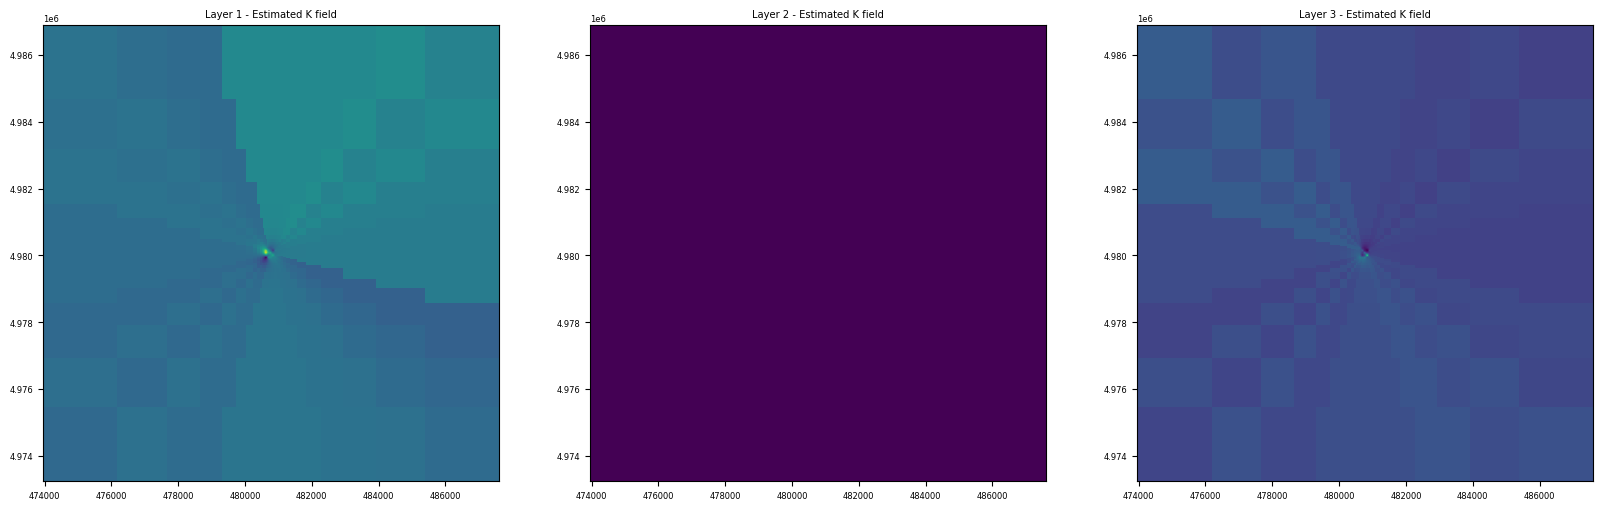

In [104]:
fig = plt.figure(figsize=(20, 20))
for i in range(3):
    
    ax = fig.add_subplot(1, 3, i+1, aspect='equal')

    # Create a PlotMapView object
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)

    # Plot the active and inactive cells
    # In MODFLOW 6, 'IDOMAIN' array is used instead of 'IBOUND'.
    # plot_ibound() handles this automatically.
    quadmesh = mapview.plot_array(hk_array[i]) # plots K field

    # Plot the grid lines for context
    #grid_lines = mapview.plot_grid()

    # Add a title and show the plot
    ax.set_title(f"Layer {i+1} - Estimated K field")
    #plt.show()

zoom at MLAC site

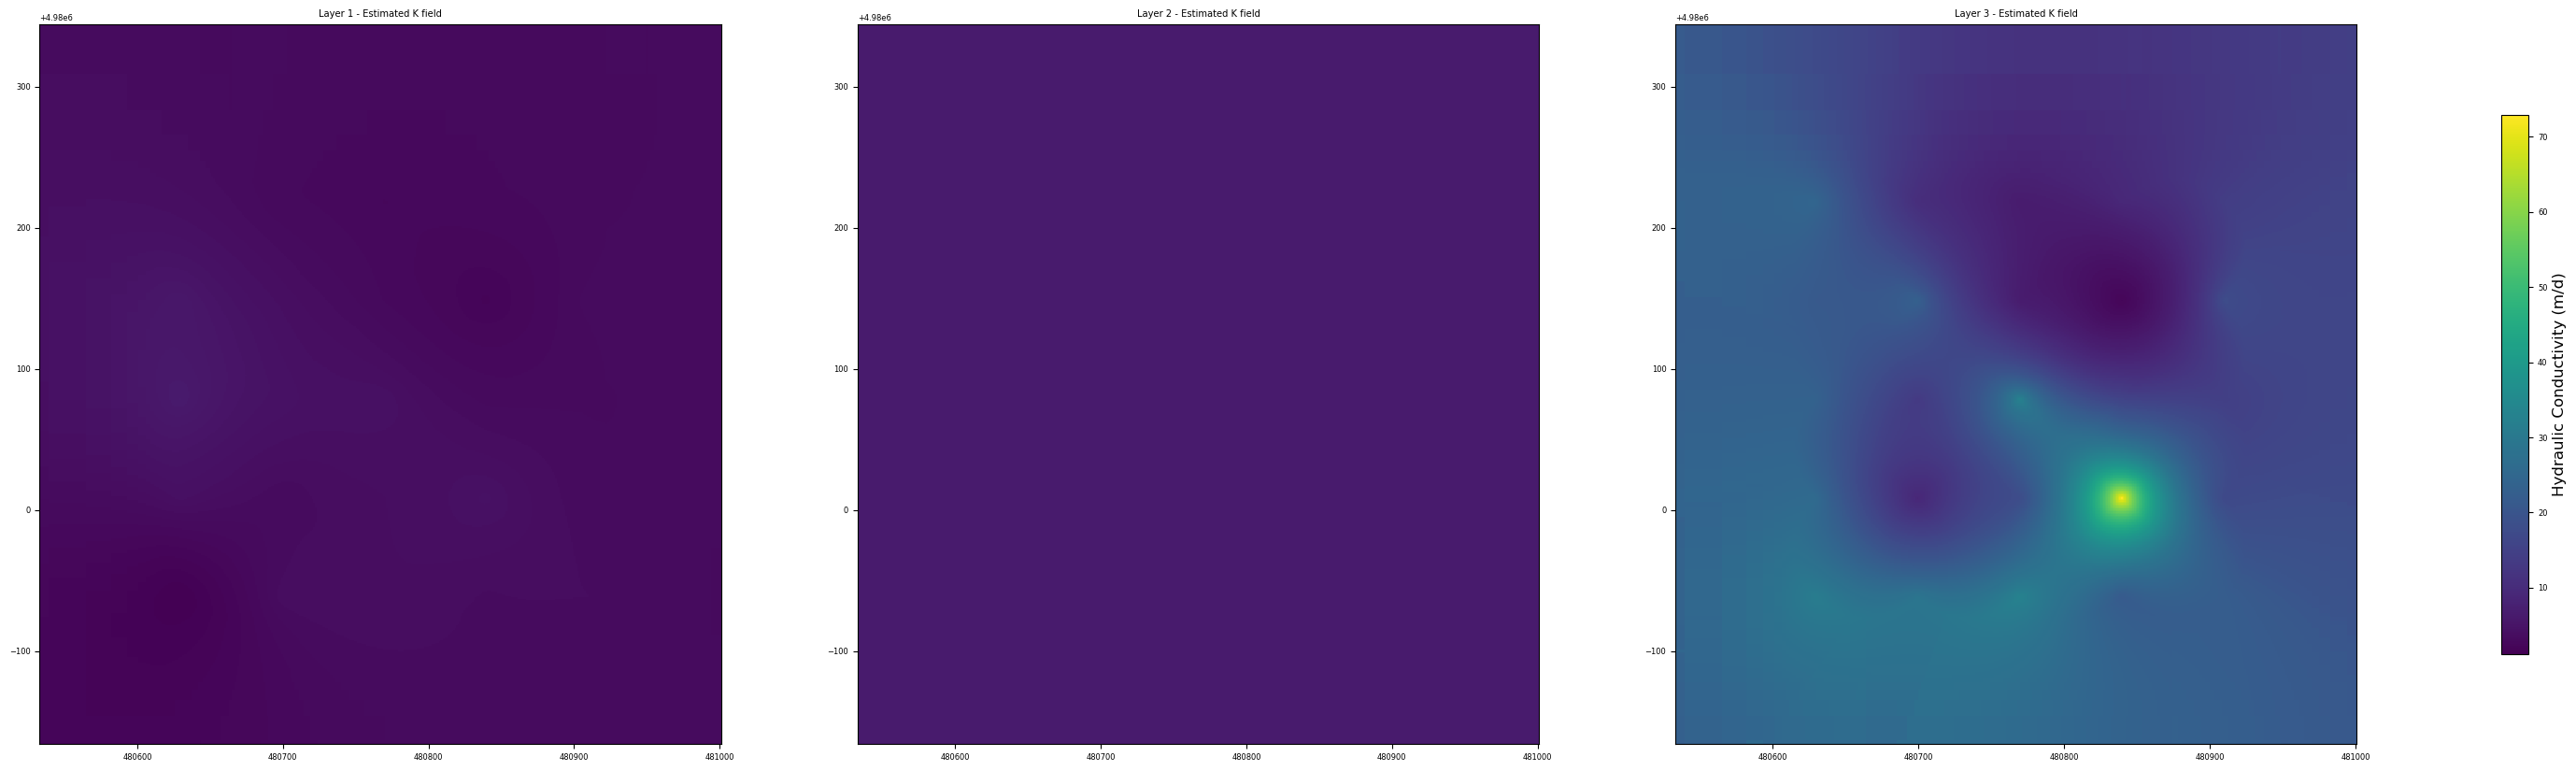

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(40,10))

# Optionally, determine common vmin and vmax for consistent color scaling
vmin = hk_array.min()
vmax = hk_array.max()

# Plot each layer
quadmesh_list = []
for i, ax in enumerate(axes):
    mapview = flopy.plot.PlotMapView(model=gwf, ax=ax)
    quadmesh = mapview.plot_array(hk_array[i], vmin=vmin, vmax=vmax)
    quadmesh_list.append(quadmesh)  # Store QuadMesh for reference
    ax.set_title(f"Layer {i+1} - Estimated K field")
    ax.set_xlim(480533, 481001)
    ax.set_ylim(4979834, 4980344)
    # Optionally add grid lines
    # mapview.plot_grid()

# Add a single colorbar for all subplots
cbar = fig.colorbar(quadmesh_list[0], ax=axes, shrink=0.75, label="Hydraulic Conductivity (m/d)")
cbar.set_label("Hydraulic Conductivity (m/d)", fontsize=12)

plt.show()

debugging